In [122]:
from sklearn.datasets import make_swiss_roll
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
X, y = make_swiss_roll(n_samples=500, noise=0.5, random_state=None, hole=False)
X.shape, y.shape

((500, 3), (500,))

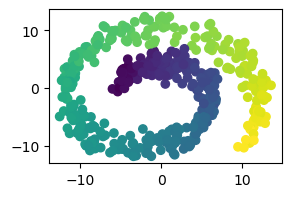

In [124]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(3,2))
plt.scatter(X_pca[:, 0], X_pca[:,1], c=y)

In [125]:
import sys
sys.path.append('./')
from limeade import LIMEADE

In [126]:
lm = LIMEADE(data=X, reduced_data=X_pca)
V = lm.fit()
global_attribution = lm.score()

Text(0.5, 1.0, 'Global attributions')

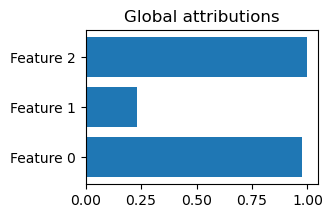

In [127]:
plt.figure(figsize=(3,2))
plt.barh(np.arange(3), global_attribution)
plt.yticks(np.arange(3), [f'Feature {i}' for i in range(3)])
plt.title('Global attributions')

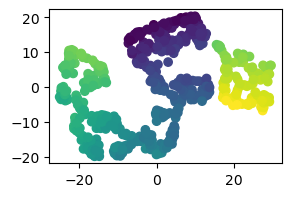

In [128]:
from sklearn.manifold import TSNE
X_tsne = TSNE(n_components=2).fit_transform(X)
plt.figure(figsize=(3,2))
plt.scatter(X_tsne[:, 0], X_tsne[:,1], c=y)

In [142]:
lm = LIMEADE(data=X, reduced_data=X_tsne)
V = lm.fit(level='local')
local_attribution = lm.score(anchor=None)

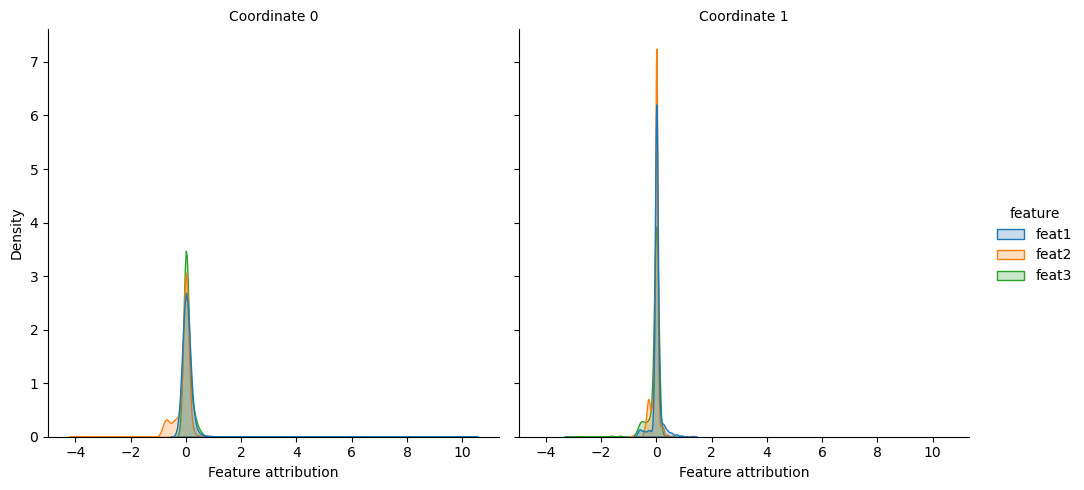

In [157]:
import pandas as pd
import seaborn as sns
df0 = pd.DataFrame(V[:, :, 0], columns=['feat1', 'feat2', 'feat3'])
df0['coord']= 0
df1 = pd.DataFrame(V[:, :, 1], columns=['feat1', 'feat2', 'feat3'])
df1['coord']= 1
df = pd.concat([df0, df1], axis=0, ignore_index=True)
df_long = df.melt(id_vars="coord",value_vars=["feat1", "feat2", "feat3"], var_name="feature", value_name="attribution")

g = sns.displot(
    data=df_long,
    x="attribution",
    hue="feature",
    col="coord",
    kind="kde",
    fill=True,
    common_norm=False,
#    height=4,
#    aspect=1.2
)

g.set_axis_labels("Feature attribution", "Density")
g.set_titles("Coordinate {col_name}")
plt.show()

Text(0.5, 1.0, 'Violin plot of local attributions')

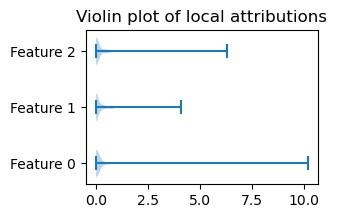

In [144]:
plt.figure(figsize=(3,2))
plt.violinplot([local_attribution[:,j] for j in range(3)], positions=np.arange(3), orientation='horizontal')
plt.yticks(np.arange(3), [f'Feature {i}' for i in range(3)])
plt.title('Violin plot of local attributions')

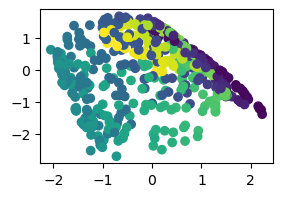

In [131]:
from sklearn.manifold import LocallyLinearEmbedding
X_lle = LocallyLinearEmbedding(n_components=2, n_neighbors=12, method='hessian', eigen_solver='auto', random_state=0).fit_transform(X)
from sklearn.preprocessing import StandardScaler
X_lle=StandardScaler().fit_transform(X_lle)
plt.figure(figsize=(3,2))
plt.scatter(X_lle[:, 0], X_lle[:,1], c=y)

In [132]:
lm = LIMEADE(data=X, reduced_data=X_lle)
V = lm.fit(level='global')
global_attribution = lm.score(anchor=None)

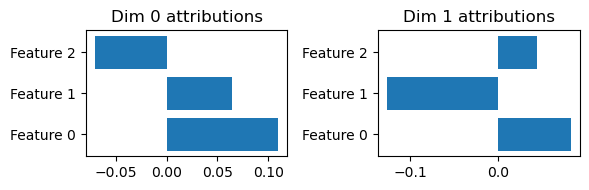

In [133]:
fig = plt.figure(figsize=(6,2))
ax = fig.add_subplot(121)
ax.barh(np.arange(3), V[:,0])
ax.set_yticks(np.arange(3), [f'Feature {i}' for i in range(3)])
ax.set_title('Dim 0 attributions')
ax = fig.add_subplot(122)
ax.barh(np.arange(3), V[:,1])
ax.set_yticks(np.arange(3), [f'Feature {i}' for i in range(3)])
ax.set_title('Dim 1 attributions')
fig.tight_layout()

Text(0.5, 1.0, 'Global attributions')

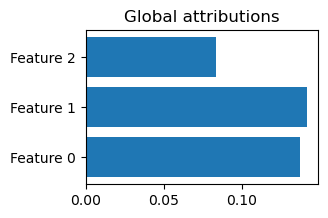

In [134]:
plt.figure(figsize=(3,2))
plt.barh(np.arange(3), global_attribution)
plt.yticks(np.arange(3), [f'Feature {i}' for i in range(3)])
plt.title('Global attributions')

In [135]:
lm = LIMEADE(data=X, reduced_data=X_lle)
V = lm.fit(level='local')
local_attribution = lm.score()

In [136]:
local_attribution

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       ...,
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [137]:
np.mean(V,axis=0)

array([[0., 0.],
       [0., 0.],
       [0., 0.]])